# Demonstrating doves movie regen
VR March 5, 2026

In [1]:
import retinanalysis as ra
import matplotlib.pyplot as plt
from IPython.display import HTML

[2026-03-06 13:26:48,135][INFO]: DataJoint 0.14.4 connected to root@127.0.0.1:3306


Can fetch single cell data Sam pointed me to, or MEA data I'm used to.

In [2]:
# exp_name = '2026-02-24_E_2'
exp_name = '20230725C'
df_exp = ra.get_exp_summary(exp_name)
# df_exp.query('cell_label=="Cell6" & protocol_name=="manookinlab.protocols.DovesMovie"')
df_exp.query('protocol_name=="manookinlab.protocols.DovesMovie"')

,exp_name,prep_label,datafile_name,group_label,NDF,chunk_name,protocol_name,duration_minutes,minutes_since_start,start_time,end_time,data_dir,experiment_id,prep_id,group_id,block_id,chunk_id,protocol_id
6,20230725C,Mount1,data006,Doves,0.0,chunk1,manookinlab.protocols.DovesMovie,11.18,111.13,2023-07-25 11:40:14,2023-07-25 11:51:25,20230725C/data006,62,64,1359,2097,186,9
15,20230725C,Mount1,data015,Doves mesopic,2.0,chunk2,manookinlab.protocols.DovesMovie,11.18,281.85,2023-07-25 14:30:57,2023-07-25 14:42:08,20230725C/data015,62,64,1366,2106,187,9
31,20230725C,Mount1,data031,Doves scotopic,4.0,chunk3,manookinlab.protocols.DovesMovie,11.18,474.70,2023-07-25 17:43:48,2023-07-25 17:54:59,20230725C/data031,62,64,1373,2122,188,9


Load stim block

In [3]:
# bid = df_exp.at[19, 'block_id']
# sb = ra.StimBlock(exp_name, bid)
sb = ra.MEAStimBlock(exp_name, 'data006')
sb

Initializing StimBlock for 20230725C block 2097
For Rig C 20230725C:
{'disp_type': 'OLED', 'mu_per_pixel': 3.8, 'n_ht': 600, 'n_wt': 800, 'mean_frame_rate': 60.31807657, 'stage_frame_rate': 60.0}
Nearest noise chunk for data006 is chunk2 with distance 111 minutes.



MEAStimBlock with properties:
  exp_name: 20230725C
  block_id: 2097
  b_LED: False (whether LED stimulus)
  d_display with keys: dict_keys(['disp_type', 'mu_per_pixel', 'n_ht', 'n_wt', 'mean_frame_rate', 'stage_frame_rate'])
  prep_label: Mount1
  datafile_name: data006
  chunk_name: chunk1
  protocol_name: manookinlab.protocols.DovesMovie
  noise_protocol_name: manookinlab.protocols.FastNoise
  nearest_noise_chunk: chunk2
  parameter_names of length: 32
  d_epoch_block_params with keys: dict_keys(['amp', 'preTime', 'stimTime', 'tailTime', 'waitTime', 'freezeFEMs', 'sampleRate', 'maskDiameter', 'onlineAnalysis', 'stimulusIndices', 'apertureDiameter', 'numberOfAverages', 'interpulseInterval'])
  df_epochs for 90 epochs
  d_display with keys: dict_keys(['disp_type', 'mu_per_pixel', 'n_ht', 'n_wt', 'mean_frame_rate', 'stage_frame_rate'])

In [4]:
sb.regenerate_stimulus(
    # Only doing first epoch, you can leave out this arg for regenerating all epochs
    ls_epochs = [0], 
    str_manookin_pkg_dir='/Users/riekelabbackup/Desktop/Vyom/stim_packages/manookin-package',
    d_display=sb.d_display,
    verbose=True,
    # Downsample params, arbitrary in SC but in MEA I typically go to noise stixel space
    b_ds_to_stix=True,
    stix_dims=(75, 100) # Old stixel space for OLED display, LCR is (127,203)
)

Regenerating stimulus for epochs: [0] in block: 2097
Using regeneration function: make_all_doves_movies
Processing epoch 1/1
Movie params: 
    magnificationFactor: 1.0
    stimulusIndex: 2 (matlab 1-based index)
    waitTime: 1.00 s
    stimTime: 6.00 s
    wait_frames: 60
    total_frames: 360
Loading image imk00031.iml from /Users/riekelabbackup/Desktop/Vyom/stim_packages/manookin-package/resources/doves/images/imk00031.iml
Creating movie for imk00031.iml with shape (1024, 1536) and scene size [1024 1536], fitting in [600 800]
And downsampling to stix dims (75, 100).


Generating frames: 100%|██████████| 300/300 [00:01<00:00, 226.92it/s]


Adding 60 wait frames to (300, 75, 100) for 1.0 s.
New frames shape: (360, 75, 100)
Movie scaled to (-1, 1) contrast: min -0.93, max 0.79
All movies have same frame count of 360, stacking into array.
Regenerated stimulus with keys: ['movies', 'image_names', 'images', 'center_x_pos', 'center_y_pos']


Animating the movie

In [5]:
def animate_vid(vid, interval=100, rescale=True):
    from matplotlib import animation
    import matplotlib.pyplot as plt
    if rescale:
        vid = (vid+1)/2
    fig, ax = plt.subplots()
    # ax.axis('off')
    im = ax.imshow(vid[0, ...], cmap='gray', vmin=0, vmax=1)
    plt.close()

    def init():
        im.set_array(vid[0, ...])
        return im

    def animate(i):
        im.set_array(vid[i, ...])
        return im

    ani = animation.FuncAnimation(fig, animate, frames=vid.shape[0], init_func=init, interval=interval)
    return ani

In [ ]:
# Scale from (-1,1) to (0,1) for plotting
movie = sb.stim_data['movies'][0]
ani_input = (movie + 1)/2
ani = animate_vid(ani_input,1/(60.3*2)*1e3, False)
HTML(ani.to_jshtml())

The full image, and the display in pixels that crops the image

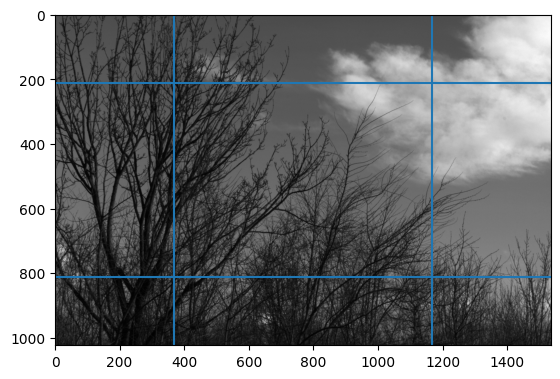

In [ ]:
img = sb.stim_data['images'][0]
plt.imshow(img, cmap='gray')
cr, cc = img.shape[0]/2, img.shape[1]/2
ht, wt = sb.d_display['n_ht'], sb.d_display['n_wt']
plt.axvline(cc-wt/2)
plt.axvline(cc+wt/2)
plt.axhline(cr-ht/2)
plt.axhline(cr+ht/2)

The eye movement trajectory in pixel space

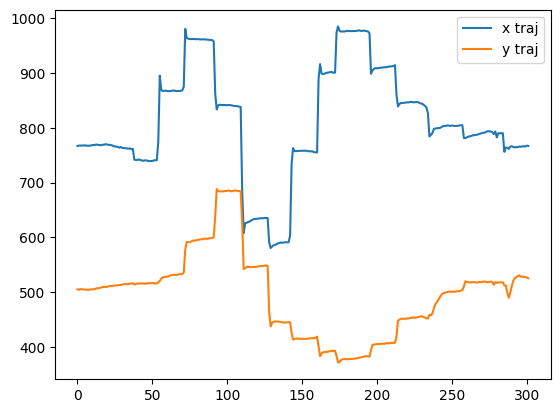

In [ ]:
plt.plot(sb.stim_data['center_x_pos'][0], label='x traj')
plt.plot(sb.stim_data['center_y_pos'][0], label='y traj')
plt.legend()